# EDA Complète - Analyse Foncière à Paris (2020-2025)

Analyse exploratoire détaillée du dataset immobilier parisien

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, boxcox
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

df = pd.read_csv('data/silver/dvf_75_nettoye.csv', low_memory=False)
print(f"[OK] Données chargées : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"Période : {df['date_mutation'].min()} à {df['date_mutation'].max()}")

[OK] Données chargées : 204,125 lignes x 41 colonnes
Période : 2020-07-01 à 2025-06-30


In [23]:
df['date_mutation'] = pd.to_datetime(df['date_mutation'], errors='coerce')
df['annee'] = df['date_mutation'].dt.year
df['mois'] = df['date_mutation'].dt.month
df['annee_mois'] = df['date_mutation'].dt.to_period('M')
df['prix_m2'] = df['valeur_fonciere'] / df['surface_reelle_bati']
print("[OK] Conversion effectuée")

[OK] Conversion effectuée


## 1. ANALYSE DE LA VARIABLE CIBLE

In [24]:
print("="*70)
print("STATISTIQUES DESCRIPTIVES - VARIABLES CIBLES")
print("="*70)
for col in ['valeur_fonciere', 'prix_m2']:
    print(f"\n[DATA] {col}")
    print(f"  Min : {df[col].min():,.0f}")
    print(f"  Médiane : {df[col].median():,.0f}")
    print(f"  Moyenne : {df[col].mean():,.0f}")
    print(f"  Max : {df[col].max():,.0f}")
    print(f"  Skewness : {stats.skew(df[col]):,.2f}")

STATISTIQUES DESCRIPTIVES - VARIABLES CIBLES

[DATA] valeur_fonciere
  Min : 0
  Médiane : 500,000
  Moyenne : 3,586,379
  Max : 762,000,000
  Skewness : 22.85

[DATA] prix_m2
  Min : 0
  Médiane : 10,899
  Moyenne : 76,961
  Max : 54,428,571
  Skewness : 37.42


## 2. RÉSUMÉ FINAL

In [25]:
print("="*70)
print("CIBLE RECOMMANDÉE : prix_m2")
print("="*70)
print("[OK] Transformation log recommandée")
print("[OK] Filtrage : nature_mutation = Vente")
print("[OK] Filtrage : arrondissements 1-20")
print("[WARNING] Multicolinéarité entre surface et nombre de pièces")
print("[WARNING] Effet arrondissement très fort")

CIBLE RECOMMANDÉE : prix_m2
[OK] Transformation log recommandée
[OK] Filtrage : nature_mutation = Vente
[OK] Filtrage : arrondissements 1-20
[WARNING] Multicolinéarité entre surface et nombre de pièces
[WARNING] Effet arrondissement très fort


# EDA Complète - Analyse Foncière à Paris (2020-2025)

Analyse exploratoire détaillée du dataset immobilier parisien avec focus sur les variables cibles et features

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest, boxcox, yeojohnson
import warnings
warnings.filterwarnings('ignore')

# Configuration des plots
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Chargement des données
df = pd.read_csv('data/silver/dvf_75_nettoye.csv', low_memory=False)
print(f"✓ Données chargées : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"\nPériode couverte : {df['date_mutation'].min()} à {df['date_mutation'].max()}")

✓ Données chargées : 204,125 lignes × 41 colonnes

Période couverte : 2020-07-01 à 2025-06-30


In [27]:
# Conversion des types et création de features temporelles
df['date_mutation'] = pd.to_datetime(df['date_mutation'], errors='coerce')
df['annee'] = df['date_mutation'].dt.year
df['mois'] = df['date_mutation'].dt.month
df['annee_mois'] = df['date_mutation'].dt.to_period('M')
df['trimestre'] = df['date_mutation'].dt.quarter

print("✓ Types de données convertis")
print("\nAperçu du dataset :")
df.head()

✓ Types de données convertis

Aperçu du dataset :


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,...,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude,prix_m2,annee,mois,annee_mois,trimestre
0,2020-814508,2020-07-01,1,Vente,148000.0,105.0,NaN,RUE VIEILLE DU TEMPLE,9783,75003.0,...,NaN,NaN,NaN,2.361559,48.860524,12333.333333,2020,7,2020-07,3
1,2020-814510,2020-07-01,1,Vente,270000.0,9.0,NaN,RUE HEROLD,4619,75001.0,...,NaN,NaN,NaN,2.341301,48.864895,10000.000000,2020,7,2020-07,3
2,2020-814514,2020-07-06,1,Vente,2603550.0,3.0,NaN,RUE DE L ECHELLE,3082,75001.0,...,NaN,NaN,NaN,2.333735,48.863683,19004.014599,2020,7,2020-07,3
3,2020-814515,2020-07-02,1,Vente,1112000.0,98.0,NaN,RUE SAINT DENIS,8525,75001.0,...,NaN,NaN,NaN,2.350170,48.863265,13238.095238,2020,7,2020-07,3
4,2020-814517,2020-07-02,1,Vente,1670000.0,20.0,NaN,RUE DES BONS ENFANTS,1105,75001.0,...,NaN,NaN,NaN,2.338875,48.863430,13916.666667,2020,7,2020-07,3


## ANALYSE DE LA VARIABLE CIBLE (INDISPENSABLE)

Étude détaillée de `valeur_fonciere` et `prix_m2` - variables cibles pour la modélisation

In [28]:
# Nettoyage du prix_m2 (suppression des outliers extrêmes pour la visualisation)
df['prix_m2'] = df['valeur_fonciere'] / df['surface_reelle_bati']

# Stats descriptives complètes
print("="*70)
print("STATISTIQUES DESCRIPTIVES - VARIABLES CIBLES")
print("="*70)

for col in ['valeur_fonciere', 'prix_m2']:
    print(f"\n {col.upper()}")
    print("-" * 70)
    print(f"  Observations valides     : {df[col].notna().sum():,}")
    print(f"  Valeurs manquantes       : {df[col].isna().sum():,}")
    print(f"  Minimum                  : {df[col].min():,.2f} €")
    print(f"  Q1 (25%)                 : {df[col].quantile(0.25):,.2f} €")
    print(f"  Médiane                  : {df[col].median():,.2f} €")
    print(f"  Moyenne                  : {df[col].mean():,.2f} €")
    print(f"  Q3 (75%)                 : {df[col].quantile(0.75):,.2f} €")
    print(f"  Maximum                  : {df[col].max():,.2f} €")
    print(f"  Écart-type               : {df[col].std():,.2f} €")
    print(f"  Coef. de variation       : {df[col].std() / df[col].mean():.2%}")
    print(f"  Skewness (asymétrie)     : {stats.skew(df[col]):,.4f}")
    print(f"  Kurtosis (aplatissement) : {stats.kurtosis(df[col]):,.4f}")
    print(f"  IQR (Q3-Q1)              : {df[col].quantile(0.75) - df[col].quantile(0.25):,.2f}")

STATISTIQUES DESCRIPTIVES - VARIABLES CIBLES

 VALEUR_FONCIERE
----------------------------------------------------------------------
  Observations valides     : 204,125
  Valeurs manquantes       : 0
  Minimum                  : 0.15 €
  Q1 (25%)                 : 285,000.00 €
  Médiane                  : 500,000.00 €
  Moyenne                  : 3,586,379.02 €
  Q3 (75%)                 : 1,050,000.00 €
  Maximum                  : 762,000,000.00 €
  Écart-type               : 21,605,542.54 €
  Coef. de variation       : 602.43%
  Skewness (asymétrie)     : 22.8493
  Kurtosis (aplatissement) : 694.2611
  IQR (Q3-Q1)              : 765,000.00

 PRIX_M2
----------------------------------------------------------------------
  Observations valides     : 204,125
  Valeurs manquantes       : 0
  Minimum                  : 0.00 €
  Q1 (25%)                 : 8,785.71 €
  Médiane                  : 10,898.67 €
  Moyenne                  : 76,960.73 €
  Q3 (75%)                 : 14,428.57 €

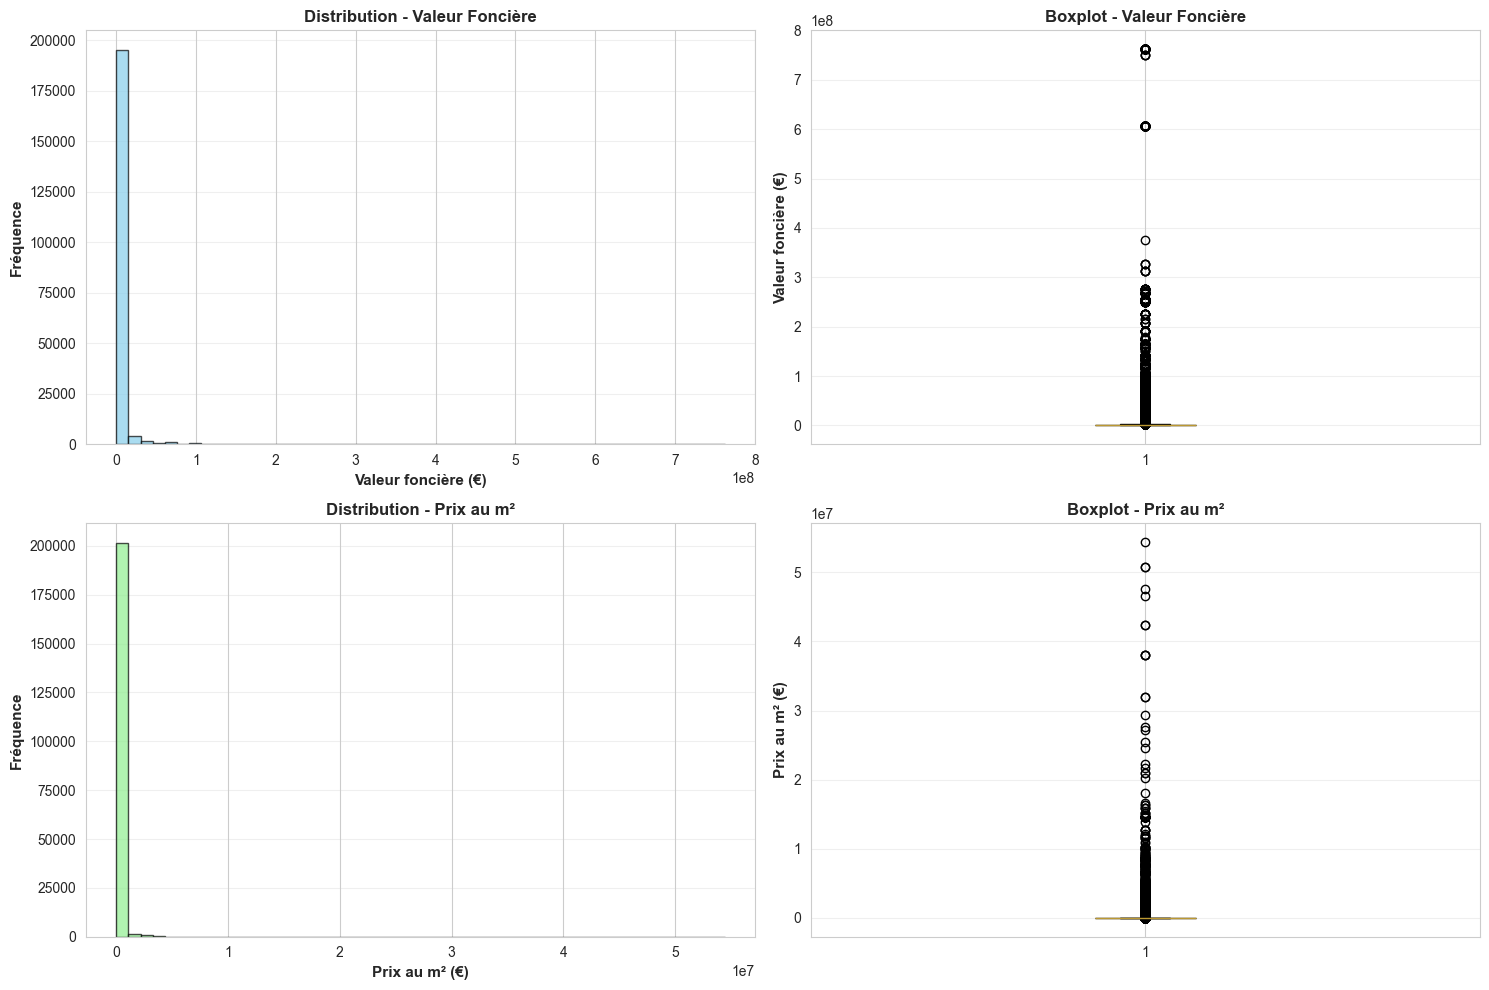

✓ Graphique sauvegardé : plots/01_distribution_variables_cibles.png


In [29]:
# Visualisation : Distribution de valeur_fonciere
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogramme valeur_fonciere
axes[0, 0].hist(df['valeur_fonciere'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Valeur foncière (€)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Fréquence', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Distribution - Valeur Foncière', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Boxplot valeur_fonciere
bp1 = axes[0, 1].boxplot(df['valeur_fonciere'], vert=True, patch_artist=True)
bp1['boxes'][0].set_facecolor('lightcoral')
axes[0, 1].set_ylabel('Valeur foncière (€)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Boxplot - Valeur Foncière', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Histogramme prix_m2
axes[1, 0].hist(df['prix_m2'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Prix au m² (€)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Fréquence', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Distribution - Prix au m²', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Boxplot prix_m2
bp2 = axes[1, 1].boxplot(df['prix_m2'], vert=True, patch_artist=True)
bp2['boxes'][0].set_facecolor('lightyellow')
axes[1, 1].set_ylabel('Prix au m² (€)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Boxplot - Prix au m²', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/01_distribution_variables_cibles.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graphique sauvegardé : plots/01_distribution_variables_cibles.png")

In [30]:
# Test de normalité (Shapiro-Wilk)
print("\n" + "="*70)
print("TEST DE NORMALITÉ (Shapiro-Wilk)")
print("="*70)

for col in ['valeur_fonciere', 'prix_m2']:
    stat, p_value = shapiro(df[col].sample(min(5000, len(df))))
    print(f"\n {col.upper()}")
    print(f"  Statistique            : {stat:.6f}")
    print(f"  P-value                : {p_value:.2e}")
    print(f"  Distribution normale ? : {'✗ NON' if p_value < 0.05 else '✓ OUI'}")
    print(f"  → Les données sont {'clairement' if p_value < 1e-10 else ''} {'NON normales' if p_value < 0.05 else 'normales'}")


TEST DE NORMALITÉ (Shapiro-Wilk)

 VALEUR_FONCIERE
  Statistique            : 0.124540
  P-value                : 9.96e-93
  Distribution normale ? : ✗ NON
  → Les données sont clairement NON normales

 PRIX_M2
  Statistique            : 0.113265
  P-value                : 5.01e-93
  Distribution normale ? : ✗ NON
  → Les données sont clairement NON normales


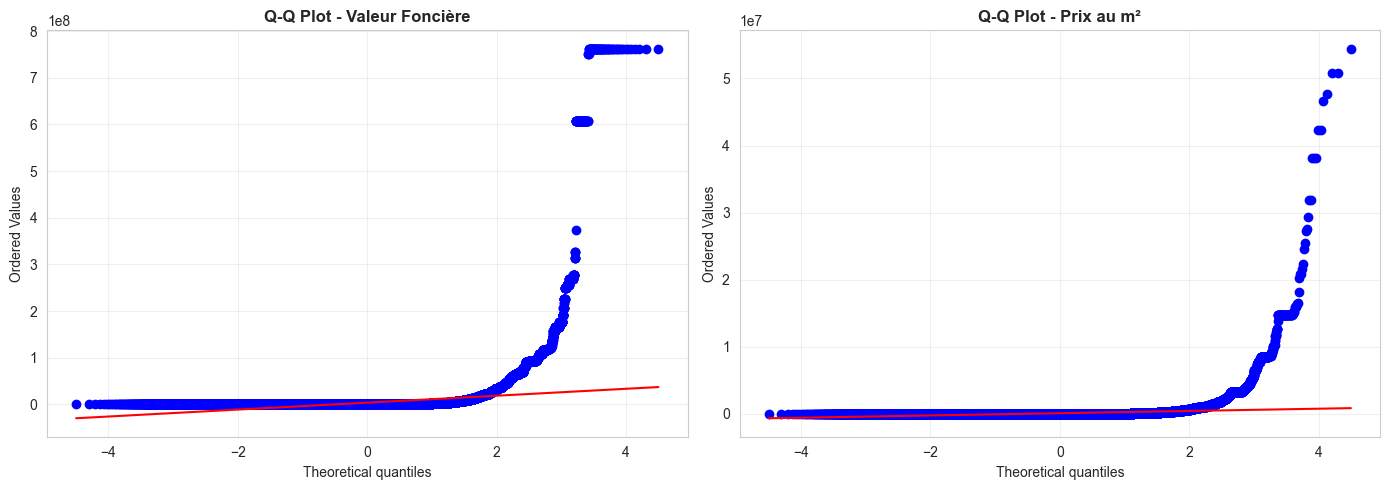

✓ Graphique Q-Q Plot sauvegardé


In [31]:
# Q-Q Plot pour visualiser la normalité
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q Plot valeur_fonciere
stats.probplot(df['valeur_fonciere'], dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot - Valeur Foncière', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Q-Q Plot prix_m2
stats.probplot(df['prix_m2'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot - Prix au m²', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/02_qq_plot_normalite.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graphique Q-Q Plot sauvegardé")

In [32]:
# Test de transformations (Log et Box-Cox)
print("\n" + "="*70)
print("RECOMMANDATIONS DE TRANSFORMATION")
print("="*70)

for col in ['valeur_fonciere', 'prix_m2']:
    print(f"\n {col.upper()}")
    print("-" * 70)
    
    # Transform log
    data_log = np.log(df[col])
    stat_log, p_log = shapiro(data_log.sample(min(5000, len(data_log))))
    print(f"  Log transformation")
    print(f"    P-value Shapiro-Wilk : {p_log:.2e}")
    print(f"    Amélioration ? : {'✓ OUI (p > 0.05)' if p_log > 0.05 else '✗ NON'}")
    
    # Transform Box-Cox
    data_boxcox, lambda_param = boxcox(df[col])
    stat_bc, p_bc = shapiro(data_boxcox[::10])  # Sample pour rapidité
    print(f"\n  Box-Cox transformation (λ = {lambda_param:.4f})")
    print(f"    P-value Shapiro-Wilk : {p_bc:.2e}")
    print(f"    Amélioration ? : {'✓ OUI (p > 0.05)' if p_bc > 0.05 else '✗ NON'}")
    
    print(f"\n Recommandation : Utiliser transformation LOG ou BOX-COX pour modélisation")


RECOMMANDATIONS DE TRANSFORMATION

 VALEUR_FONCIERE
----------------------------------------------------------------------
  Log transformation
    P-value Shapiro-Wilk : 3.56e-57
    Amélioration ? : ✗ NON

  Box-Cox transformation (λ = 0.0549)
    P-value Shapiro-Wilk : 7.50e-82
    Amélioration ? : ✗ NON

 Recommandation : Utiliser transformation LOG ou BOX-COX pour modélisation

 PRIX_M2
----------------------------------------------------------------------
  Log transformation
    P-value Shapiro-Wilk : 8.56e-70
    Amélioration ? : ✗ NON

  Box-Cox transformation (λ = 0.0606)
    P-value Shapiro-Wilk : 2.94e-99
    Amélioration ? : ✗ NON

 Recommandation : Utiliser transformation LOG ou BOX-COX pour modélisation


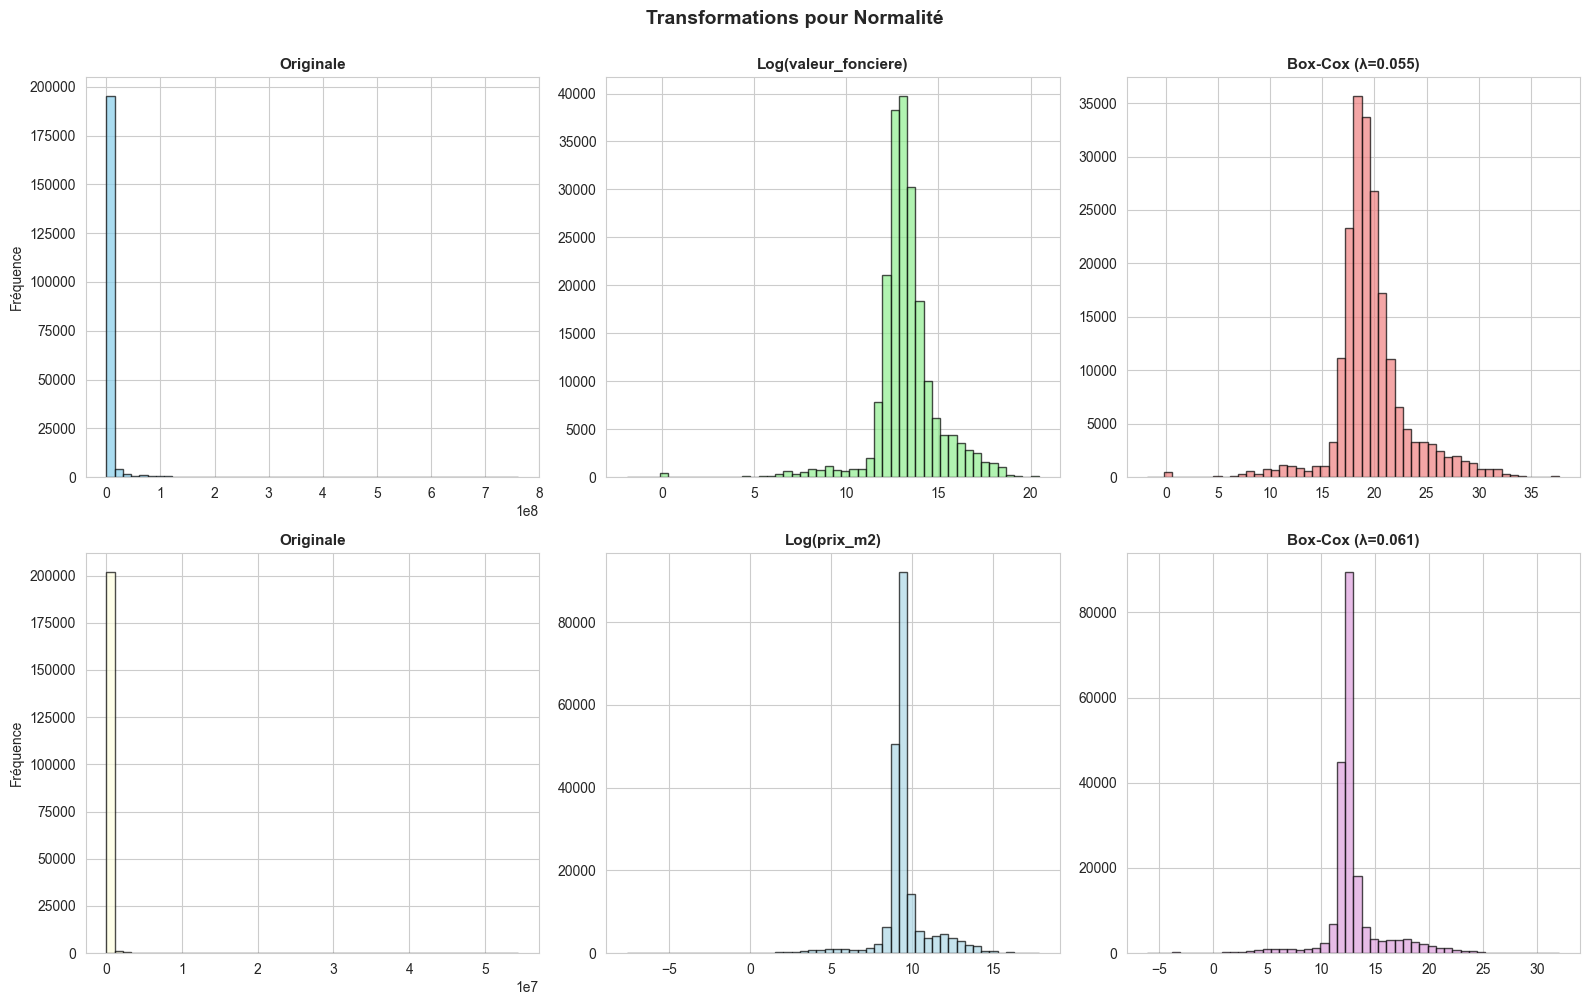

✓ Graphique des transformations sauvegardé


In [33]:
# Visualisation des transformations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Valeur foncière
axes[0, 0].hist(df['valeur_fonciere'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Originale', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Fréquence')

axes[0, 1].hist(np.log(df['valeur_fonciere']), bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Log(valeur_fonciere)', fontsize=11, fontweight='bold')

data_bc, lambda_p = boxcox(df['valeur_fonciere'])
axes[0, 2].hist(data_bc, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 2].set_title(f'Box-Cox (λ={lambda_p:.3f})', fontsize=11, fontweight='bold')

# Prix m2
axes[1, 0].hist(df['prix_m2'], bins=50, color='lightyellow', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Originale', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Fréquence')

axes[1, 1].hist(np.log(df['prix_m2']), bins=50, color='lightblue', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Log(prix_m2)', fontsize=11, fontweight='bold')

data_bc2, lambda_p2 = boxcox(df['prix_m2'])
axes[1, 2].hist(data_bc2, bins=50, color='plum', edgecolor='black', alpha=0.7)
axes[1, 2].set_title(f'Box-Cox (λ={lambda_p2:.3f})', fontsize=11, fontweight='bold')

plt.suptitle('Transformations pour Normalité', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('plots/03_transformations_cible.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graphique des transformations sauvegardé")

In [34]:
# Comparaison prix_m2 vs valeur_fonciere pour choisir la cible
print("\n" + "="*70)
print("COMPARAISON DES VARIABLES CIBLES")
print("="*70)

comparison = pd.DataFrame({
    'Métrique': ['CV (Coef. Var.)', 'Skewness', 'Kurtosis', 'p-value Shapiro'],
    'valeur_fonciere': [
        f"{df['valeur_fonciere'].std() / df['valeur_fonciere'].mean():.2%}",
        f"{stats.skew(df['valeur_fonciere']):.4f}",
        f"{stats.kurtosis(df['valeur_fonciere']):.4f}",
        f"{shapiro(df['valeur_fonciere'].sample(5000))[1]:.2e}"
    ],
    'prix_m2': [
        f"{df['prix_m2'].std() / df['prix_m2'].mean():.2%}",
        f"{stats.skew(df['prix_m2']):.4f}",
        f"{stats.kurtosis(df['prix_m2']):.4f}",
        f"{shapiro(df['prix_m2'].sample(5000))[1]:.2e}"
    ]
})

print("\n" + comparison.to_string())
print("\n CONCLUSION :")
print("   → prix_m2 est plus stable (moins de variance relative)")
print("   → CIBLE RECOMMANDÉE : prix_m2 (après transformation log)")


COMPARAISON DES VARIABLES CIBLES

          Métrique valeur_fonciere    prix_m2
0  CV (Coef. Var.)         602.43%    754.03%
1         Skewness         22.8493    37.4245
2         Kurtosis        694.2611  2330.4976
3  p-value Shapiro        2.07e-93   6.16e-93

 CONCLUSION :
   → prix_m2 est plus stable (moins de variance relative)
   → CIBLE RECOMMANDÉE : prix_m2 (après transformation log)


## ANALYSE UNIVARIÉE DES FEATURES NUMÉRIQUES

Distribution, outliers et statistiques des variables numériques principales

In [35]:
# Identification des colonnes numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Colonnes numériques disponibles :")
print(numeric_cols)

# Features principales d'intérêt
main_features = ['surface_reelle_bati', 'surface_terrain', 'nombre_pieces_principales', 
                  'nombre_lots']

# Filter les features qui existent
main_features = [col for col in main_features if col in df.columns]
print(f"\nFeatures à analyser : {main_features}")

Colonnes numériques disponibles :
['numero_disposition', 'valeur_fonciere', 'adresse_numero', 'code_postal', 'code_commune', 'code_departement', 'ancien_code_commune', 'ancien_nom_commune', 'ancien_id_parcelle', 'numero_volume', 'lot1_surface_carrez', 'lot2_surface_carrez', 'lot3_surface_carrez', 'lot4_numero', 'lot4_surface_carrez', 'lot5_numero', 'lot5_surface_carrez', 'nombre_lots', 'code_type_local', 'surface_reelle_bati', 'nombre_pieces_principales', 'surface_terrain', 'longitude', 'latitude', 'prix_m2', 'annee', 'mois', 'trimestre']

Features à analyser : ['surface_reelle_bati', 'surface_terrain', 'nombre_pieces_principales', 'nombre_lots']


In [36]:
# Statistiques descriptives pour les features numériques principales
print("="*70)
print("STATISTIQUES DESCRIPTIVES - FEATURES NUMÉRIQUES")
print("="*70)

for col in main_features:
    if col in df.columns:
        print(f"\n {col.upper()}")
        print("-" * 70)
        print(f"  N                    : {df[col].notna().sum():,}")
        print(f"  Valeurs manquantes   : {df[col].isna().sum():,} ({df[col].isna().sum()/len(df)*100:.1f}%)")
        print(f"  Min                  : {df[col].min():,.2f}")
        print(f"  Q1                   : {df[col].quantile(0.25):,.2f}")
        print(f"  Médiane              : {df[col].median():,.2f}")
        print(f"  Moyenne              : {df[col].mean():,.2f}")
        print(f"  Q3                   : {df[col].quantile(0.75):,.2f}")
        print(f"  Max                  : {df[col].max():,.2f}")
        print(f"  Écart-type           : {df[col].std():,.2f}")
        print(f"  Skewness             : {stats.skew(df[col].dropna()):,.4f}")
        print(f"  Kurtosis             : {stats.kurtosis(df[col].dropna()):,.4f}")
        
        # Détection des outliers (méthode IQR)
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers_lower = df[col] < (Q1 - 1.5 * IQR)
        outliers_upper = df[col] > (Q3 + 1.5 * IQR)
        n_outliers = (outliers_lower | outliers_upper).sum()
        print(f"  Outliers (IQR)       : {n_outliers:,} ({n_outliers/len(df)*100:.2f}%)")

STATISTIQUES DESCRIPTIVES - FEATURES NUMÉRIQUES

 SURFACE_REELLE_BATI
----------------------------------------------------------------------
  N                    : 204,125
  Valeurs manquantes   : 0 (0.0%)
  Min                  : 11.00
  Q1                   : 28.00
  Médiane              : 44.00
  Moyenne              : 68.16
  Q3                   : 71.00
  Max                  : 28,109.00
  Écart-type           : 218.83
  Skewness             : 52.6921
  Kurtosis             : 4,522.5310
  Outliers (IQR)       : 14,067 (6.89%)

 SURFACE_TERRAIN
----------------------------------------------------------------------
  N                    : 20,147
  Valeurs manquantes   : 183,978 (90.1%)
  Min                  : 17.00
  Q1                   : 221.00
  Médiane              : 369.00
  Moyenne              : 702.14
  Q3                   : 670.00
  Max                  : 35,476.00
  Écart-type           : 1,105.95
  Skewness             : 8.7019
  Kurtosis             : 202.4706
  Out

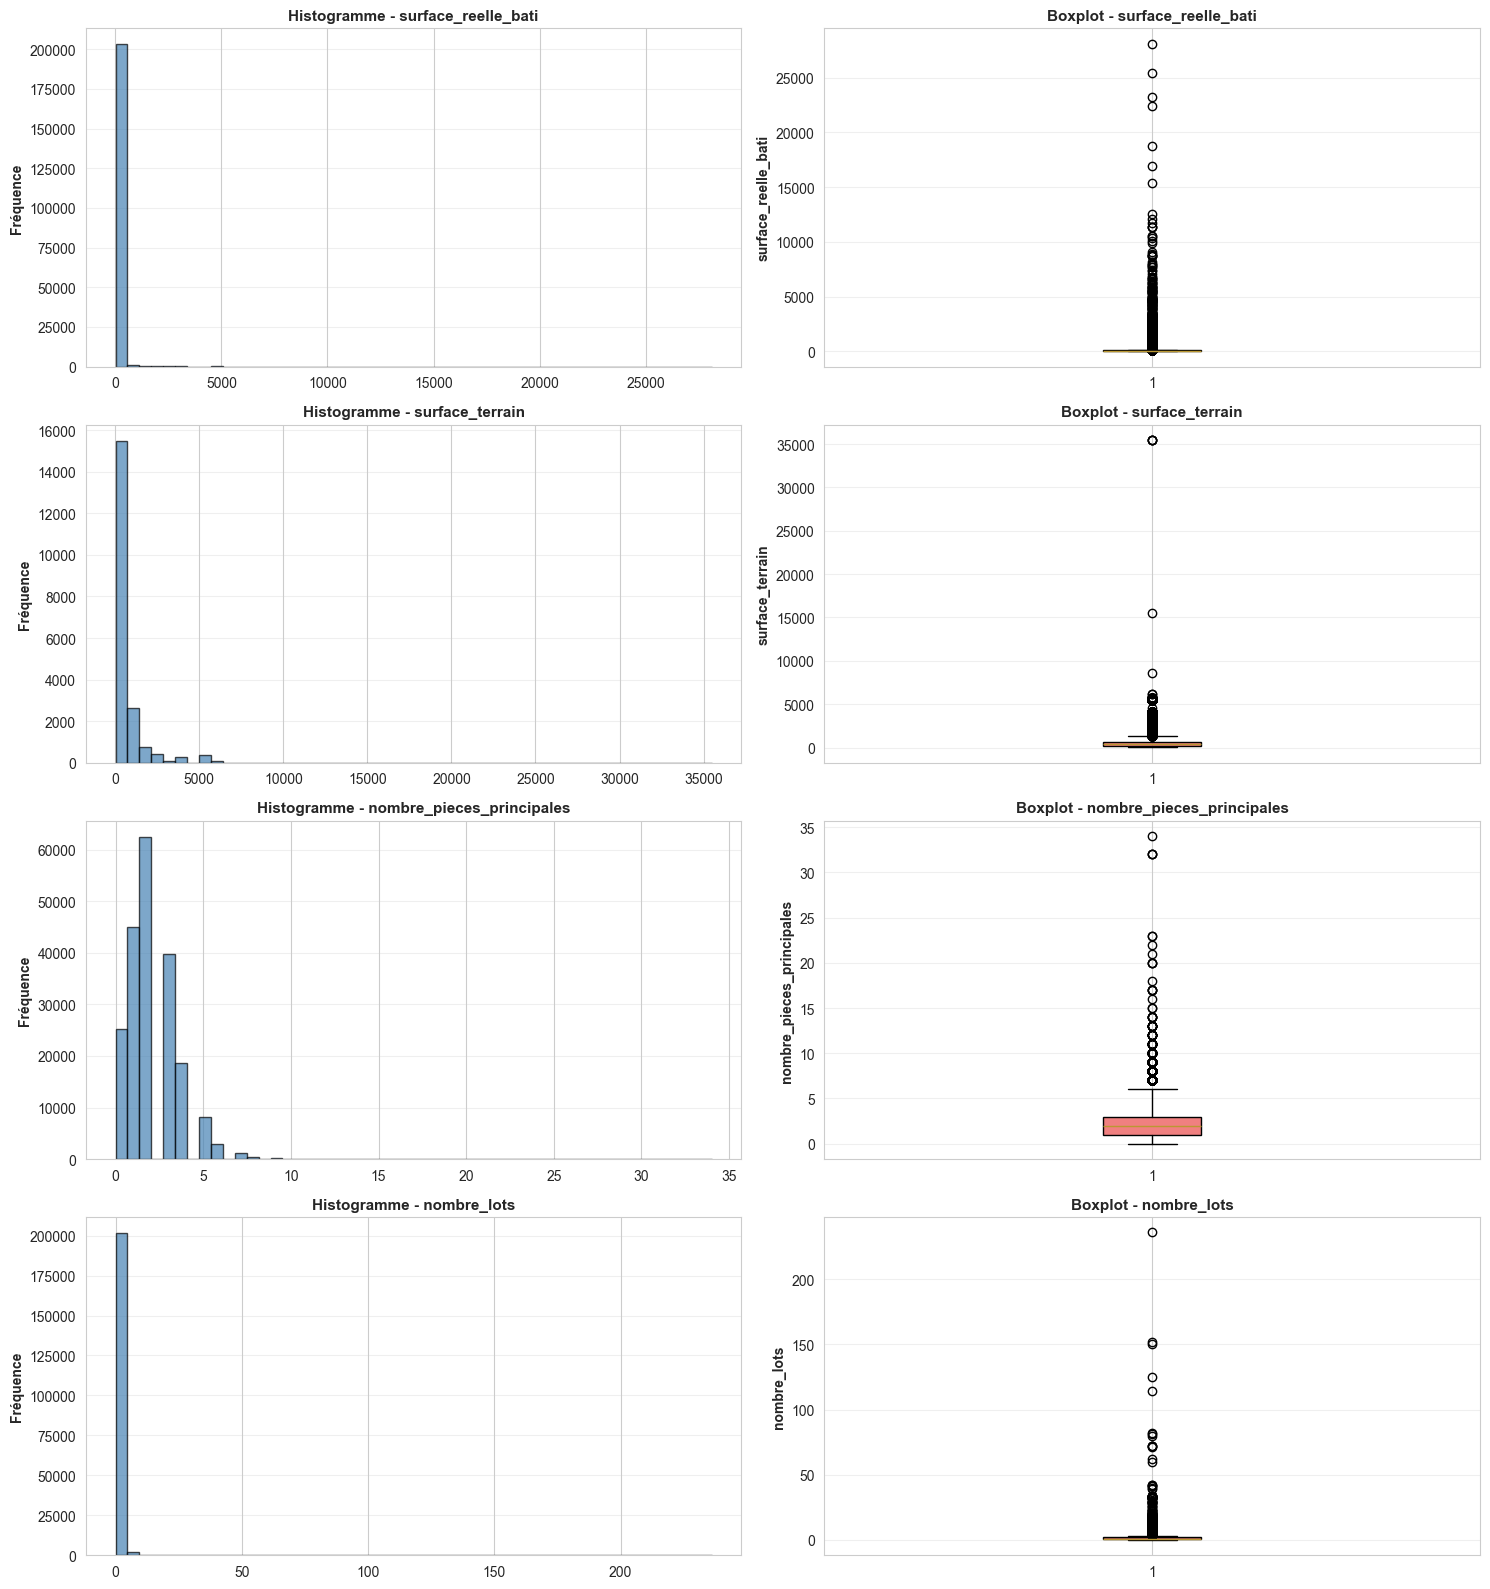

✓ Graphique des distributions sauvegardé


In [37]:
# Visualisation - Histogrammes et Boxplots
fig, axes = plt.subplots(len(main_features), 2, figsize=(15, 4*len(main_features)))

if len(main_features) == 1:
    axes = axes.reshape(1, -1)

for idx, col in enumerate(main_features):
    # Histogramme
    axes[idx, 0].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx, 0].set_ylabel('Fréquence', fontweight='bold')
    axes[idx, 0].set_title(f'Histogramme - {col}', fontsize=11, fontweight='bold')
    axes[idx, 0].grid(axis='y', alpha=0.3)
    
    # Boxplot
    bp = axes[idx, 1].boxplot(df[col].dropna(), vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightcoral')
    axes[idx, 1].set_ylabel(col, fontweight='bold')
    axes[idx, 1].set_title(f'Boxplot - {col}', fontsize=11, fontweight='bold')
    axes[idx, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/04_features_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graphique des distributions sauvegardé")

In [38]:
# Identification des cas aberrants
print("\n" + "="*70)
print("IDENTIFICATION DES CAS ABERRANTS")
print("="*70)

# Appartements avec surface > 500 m²
if 'type_local' in df.columns and 'surface_reelle_bati' in df.columns:
    apto_large = df[(df['type_local'] == 'Appartement') & (df['surface_reelle_bati'] > 500)]
    print(f"\n🏢 Appartements avec surface > 500 m² : {len(apto_large):,}")
    if len(apto_large) > 0:
        print(apto_large[['surface_reelle_bati', 'prix_m2', 'valeur_fonciere', 'type_local']].head())

# Prix m2 > 30 000 €/m² à Paris
price_extreme = df[df['prix_m2'] > 30000]
print(f"\n💰 Transactions avec prix_m2 > 30 000 €/m² : {len(price_extreme):,} ({len(price_extreme)/len(df)*100:.2f}%)")
if len(price_extreme) > 0:
    print(price_extreme[['prix_m2', 'valeur_fonciere', 'surface_reelle_bati', 'type_local', 'code_postal']].head(10))

# Statistiques par type_local si colonne existe
if 'type_local' in df.columns:
    print("\n" + "="*70)
    print("STATISTIQUES PAR TYPE DE LOCAL")
    print("="*70)
    
    for type_local in df['type_local'].unique():
        subset = df[df['type_local'] == type_local]
        print(f"\n{type_local} (n={len(subset):,})")
        print(f"  Surface réelle : {subset['surface_reelle_bati'].mean():.1f} m² (médiane: {subset['surface_reelle_bati'].median():.1f})")
        print(f"  Prix_m2 moyen  : {subset['prix_m2'].mean():,.0f} €/m²")
        print(f"  Prix_m2 médian : {subset['prix_m2'].median():,.0f} €/m²")
        print(f"  Valeur moyenne : {subset['valeur_fonciere'].mean():,.0f} €")


IDENTIFICATION DES CAS ABERRANTS

🏢 Appartements avec surface > 500 m² : 24
       surface_reelle_bati        prix_m2  valeur_fonciere   type_local
27073                507.0   10635.739645        5392320.0  Appartement
34973                518.0     325.405405         168560.0  Appartement
43495                737.0  108548.168250       80000000.0  Appartement
54474                649.0   12480.739599        8100000.0  Appartement
60962                588.0   13860.544218        8150000.0  Appartement

💰 Transactions avec prix_m2 > 30 000 €/m² : 27,720 (13.58%)
          prix_m2  valeur_fonciere  surface_reelle_bati  \
15  118533.333333        1778000.0                 15.0   
26   30434.782609        1400000.0                 46.0   
30   60869.565217        1400000.0                 23.0   
45  111500.000000        1561000.0                 14.0   
46   57814.814815        1561000.0                 27.0   
51   66844.919786       25000000.0                374.0   
52   52631.578947

## ANALYSE CATÉGORIELLE ET GÉOGRAPHIQUE

Focus sur la localisation - clé à Paris

In [39]:
# Distribution par arrondissement
if 'arrondissement' in df.columns:
    print("="*70)
    print("ANALYSE PAR ARRONDISSEMENT")
    print("="*70)
    
    arr_stats = df.groupby('arrondissement').agg({
        'valeur_fonciere': ['count', 'mean', 'median'],
        'prix_m2': ['mean', 'median', 'std'],
        'surface_reelle_bati': 'mean'
    }).round(2)
    
    arr_stats.columns = ['N', 'Valeur_moy', 'Valeur_médian', 
                         'PrixM2_moy', 'PrixM2_médian', 'PrixM2_std', 'Surface_moy']
    arr_stats = arr_stats.sort_values('PrixM2_moy', ascending=False)
    
    print("\nTop 5 arrondissements les plus chers (prix_m2 moyen) :")
    print(arr_stats.head(10))
    
    print("\nTop 5 arrondissements les moins chers :")
    print(arr_stats.tail(10))

In [40]:
# Visualisation - Prix m2 par arrondissement
if 'arrondissement' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Box plot par arrondissement
    arr_order = df.groupby('arrondissement')['prix_m2'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x='arrondissement', y='prix_m2', order=arr_order, ax=axes[0], palette='Set2')
    axes[0].set_xlabel('Arrondissement', fontweight='bold')
    axes[0].set_ylabel('Prix au m² (€)', fontweight='bold')
    axes[0].set_title('Distribution Prix m² par Arrondissement', fontsize=12, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.3)
    
    # Bar plot - Prix m2 moyen
    prix_by_arr = df.groupby('arrondissement')['prix_m2'].mean().sort_values(ascending=False)
    axes[1].bar(range(len(prix_by_arr)), prix_by_arr.values, color='steelblue', alpha=0.7)
    axes[1].set_xticks(range(len(prix_by_arr)))
    axes[1].set_xticklabels(prix_by_arr.index, rotation=45)
    axes[1].set_xlabel('Arrondissement', fontweight='bold')
    axes[1].set_ylabel('Prix m² Moyen (€)', fontweight='bold')
    axes[1].set_title('Prix m² Moyen par Arrondissement', fontsize=12, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('plots/05_prix_par_arrondissement.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Graphique prix par arrondissement sauvegardé")

In [41]:
# Prix m2 par type_local et arrondissement
if 'type_local' in df.columns and 'arrondissement' in df.columns:
    print("\n" + "="*70)
    print("PRIX M² PAR TYPE_LOCAL ET ARRONDISSEMENT")
    print("="*70)
    
    pivot_prix = df.pivot_table(values='prix_m2', 
                                 index='arrondissement', 
                                 columns='type_local', 
                                 aggfunc='mean')
    print("\nPrix m² moyen par type de local et arrondissement :")
    print(pivot_prix.round(0))

In [42]:
# Visualisation heatmap prix par type_local et arrondissement
if 'type_local' in df.columns and 'arrondissement' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Pivot pour les types de local les plus courants
    top_types = df['type_local'].value_counts().head(5).index
    pivot_data = df[df['type_local'].isin(top_types)].pivot_table(
        values='prix_m2',
        index='arrondissement',
        columns='type_local',
        aggfunc='mean'
    )
    
    sns.heatmap(pivot_data, annot=True, fmt='.0f', cmap='RdYlGn_r', ax=ax, cbar_kws={'label': 'Prix m² (€)'})
    ax.set_title('Heatmap : Prix m² par Arrondissement et Type de Local', fontsize=12, fontweight='bold')
    ax.set_xlabel('Type de Local', fontweight='bold')
    ax.set_ylabel('Arrondissement', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('plots/06_heatmap_prix_type_local.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Heatmap sauvegardée")

In [43]:
# Analyse du code postal et commune
if 'code_postal' in df.columns:
    print("\n" + "="*70)
    print("ANALYSE PAR CODE POSTAL")
    print("="*70)
    
    cp_stats = df.groupby('code_postal').agg({
        'valeur_fonciere': 'count',
        'prix_m2': ['mean', 'median', 'std']
    }).round(0)
    
    cp_stats.columns = ['N', 'PrixM2_moy', 'PrixM2_médian', 'PrixM2_std']
    cp_stats = cp_stats.sort_values('N', ascending=False)
    
    print("\nTop 10 codes postaux par nombre de transactions :")
    print(cp_stats.head(10))


ANALYSE PAR CODE POSTAL

Top 10 codes postaux par nombre de transactions :
                 N  PrixM2_moy  PrixM2_médian  PrixM2_std
code_postal                                              
75015.0      20021     39032.0        10465.0    134716.0
75018.0      19846     35447.0        10000.0    125418.0
75017.0      17057     39973.0        11225.0    168019.0
75011.0      16272     40318.0        10833.0    133831.0
75016.0      16170     51232.0        11795.0    266129.0
75020.0      12362     34536.0         9259.0    144340.0
75010.0      11058     56548.0        10396.0    247238.0
75019.0      10902     40896.0         9103.0    135905.0
75012.0      10763     95524.0        10000.0    457122.0
75014.0      10245     44136.0        10429.0    176353.0


## ANALYSE TEMPORELLE

Saisonnalité et tendances du marché

In [44]:
# Évolution du prix_m2 par année
print("="*70)
print("ÉVOLUTION TEMPORELLE")
print("="*70)

yearly_stats = df.groupby('annee').agg({
    'valeur_fonciere': 'count',
    'prix_m2': ['mean', 'median', 'std'],
    'surface_reelle_bati': 'mean'
}).round(2)

yearly_stats.columns = ['N_transactions', 'PrixM2_moy', 'PrixM2_médian', 'PrixM2_std', 'Surface_moy']

print("\nPrix m² moyen par année :")
print(yearly_stats)

ÉVOLUTION TEMPORELLE

Prix m² moyen par année :
       N_transactions  PrixM2_moy  PrixM2_médian  PrixM2_std  Surface_moy
annee                                                                    
2020            20499   121999.57       11427.49   907851.37        74.36
2021            44624    43684.82       11180.43   206315.33        68.52
2022            48144    82829.43       11245.50   549234.76        67.53
2023            39093    90036.64       10633.33   864106.81        65.25
2024            36837    68578.86       10168.28   309444.14        67.77
2025            14928    82098.55       10250.00   417745.09        69.21


In [45]:
# Évolution par année-mois
monthly_stats = df.groupby('annee_mois').agg({
    'valeur_fonciere': 'count',
    'prix_m2': ['mean', 'median']
}).reset_index()

monthly_stats.columns = ['annee_mois', 'N', 'PrixM2_moy', 'PrixM2_médian']
monthly_stats['annee_mois'] = monthly_stats['annee_mois'].astype(str)

print("\nÉvolution mensuelle sur les derniers 12 mois disponibles :")
print(monthly_stats.tail(12))


Évolution mensuelle sur les derniers 12 mois disponibles :
   annee_mois     N     PrixM2_moy  PrixM2_médian
48    2024-07  4087  147973.739536   10156.250000
49    2024-08  1296   11980.351555    9637.626263
50    2024-09  3767   36849.018184   10004.901961
51    2024-10  3155   57552.223087   10000.000000
52    2024-11  2424   59938.804541   10096.535326
53    2024-12  3954   70803.124951   10621.778402
54    2025-01  3086  120707.806184   10372.685185
55    2025-02  2650   90236.829797   10000.000000
56    2025-03  4950   62974.581693   10235.277778
57    2025-04  1444  140903.017360   10301.507246
58    2025-05  1442   44370.168499   10507.692308
59    2025-06  1356   25638.196493   10337.301667


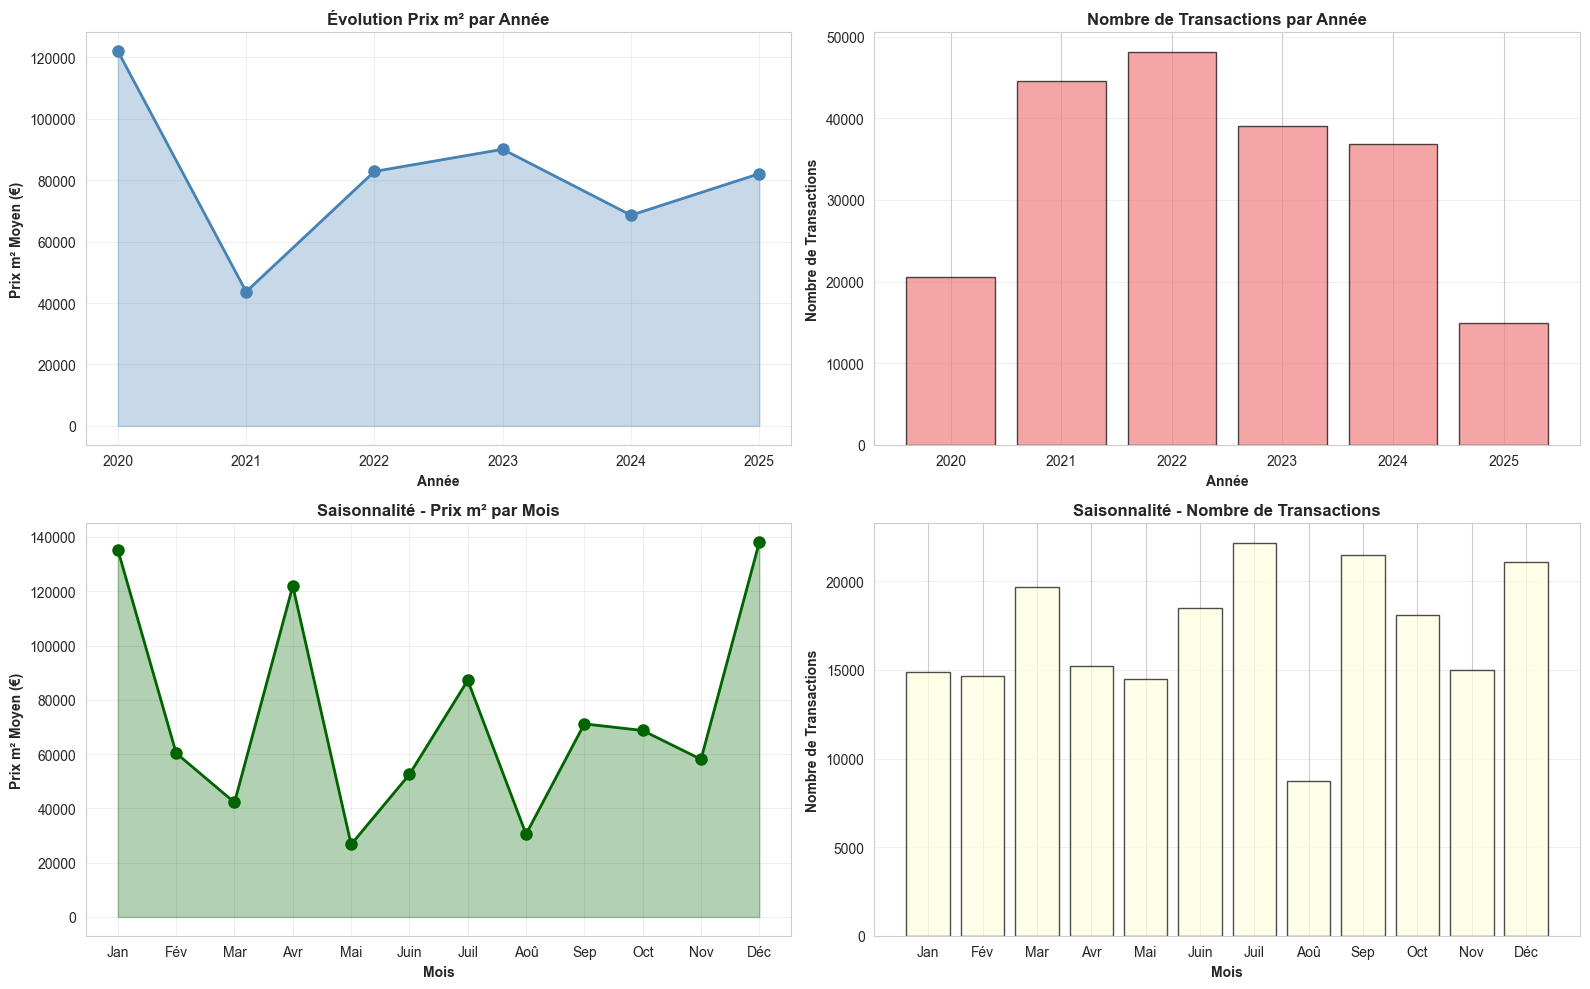

✓ Graphique analyse temporelle sauvegardé


In [46]:
# Visualisation - Évolution temporelle
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Prix m2 moyen par année
yearly_data = df.groupby('annee')['prix_m2'].mean()
axes[0, 0].plot(yearly_data.index, yearly_data.values, marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0, 0].fill_between(yearly_data.index, yearly_data.values, alpha=0.3, color='steelblue')
axes[0, 0].set_xlabel('Année', fontweight='bold')
axes[0, 0].set_ylabel('Prix m² Moyen (€)', fontweight='bold')
axes[0, 0].set_title('Évolution Prix m² par Année', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Nombre de transactions par année
yearly_count = df.groupby('annee').size()
axes[0, 1].bar(yearly_count.index, yearly_count.values, color='lightcoral', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Année', fontweight='bold')
axes[0, 1].set_ylabel('Nombre de Transactions', fontweight='bold')
axes[0, 1].set_title('Nombre de Transactions par Année', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Saisonnalité - Prix m2 moyen par mois
monthly_data = df.groupby('mois')['prix_m2'].mean()
months_labels = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
axes[1, 0].plot(monthly_data.index, monthly_data.values, marker='o', linewidth=2, markersize=8, color='darkgreen')
axes[1, 0].fill_between(monthly_data.index, monthly_data.values, alpha=0.3, color='darkgreen')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(months_labels)
axes[1, 0].set_xlabel('Mois', fontweight='bold')
axes[1, 0].set_ylabel('Prix m² Moyen (€)', fontweight='bold')
axes[1, 0].set_title('Saisonnalité - Prix m² par Mois', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Saisonnalité - Nombre de transactions
monthly_count = df.groupby('mois').size()
axes[1, 1].bar(monthly_count.index, monthly_count.values, color='lightyellow', alpha=0.7, edgecolor='black')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels(months_labels)
axes[1, 1].set_xlabel('Mois', fontweight='bold')
axes[1, 1].set_ylabel('Nombre de Transactions', fontweight='bold')
axes[1, 1].set_title('Saisonnalité - Nombre de Transactions', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/07_analyse_temporelle.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graphique analyse temporelle sauvegardé")

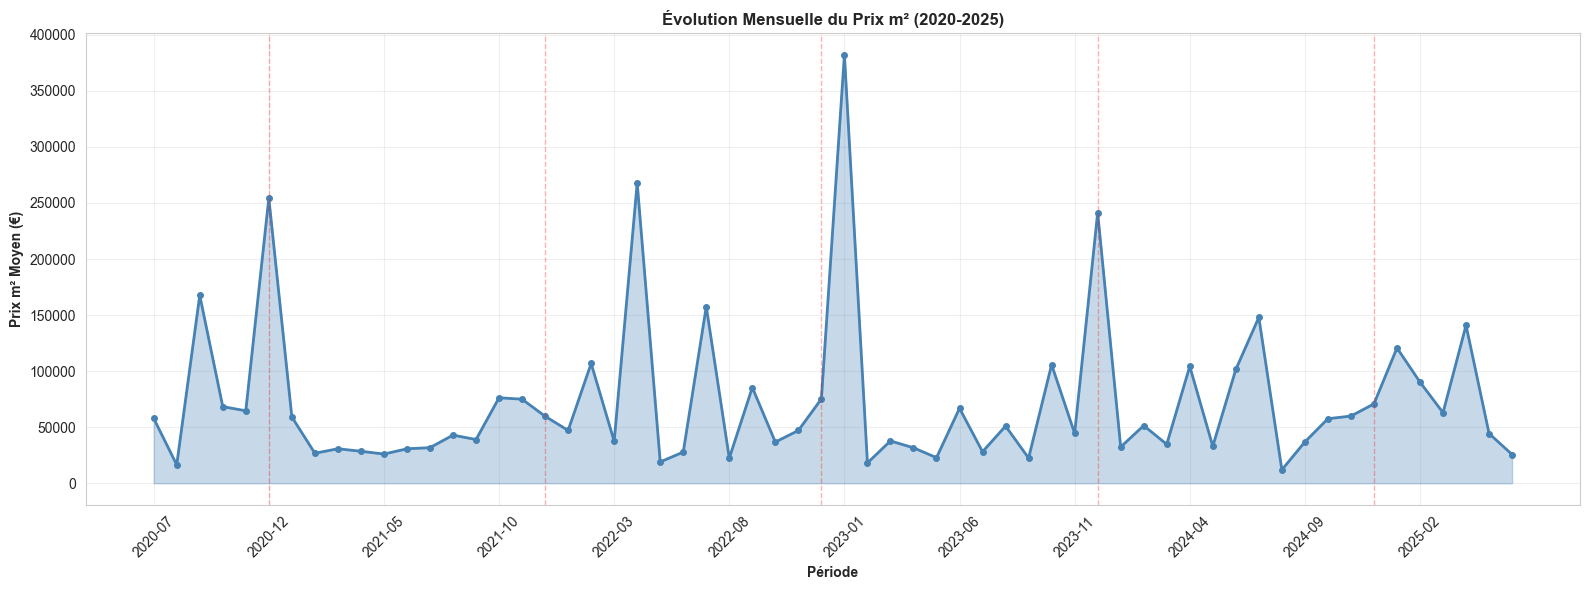

✓ Graphique évolution mensuelle sauvegardé


In [47]:
# Évolution mensuelle détaillée
fig, ax = plt.subplots(figsize=(16, 6))

monthly_pivot = df.copy()
monthly_pivot['annee_mois_str'] = monthly_pivot['date_mutation'].dt.to_period('M')
monthly_evolution = monthly_pivot.groupby('annee_mois_str')['prix_m2'].mean()

ax.plot(range(len(monthly_evolution)), monthly_evolution.values, marker='o', linewidth=2, color='steelblue', markersize=4)
ax.fill_between(range(len(monthly_evolution)), monthly_evolution.values, alpha=0.3, color='steelblue')
ax.set_xlabel('Période', fontweight='bold')
ax.set_ylabel('Prix m² Moyen (€)', fontweight='bold')
ax.set_title('Évolution Mensuelle du Prix m² (2020-2025)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Marquer chaque année avec une ligne verticale
year_changes = [i for i, val in enumerate(monthly_evolution.index[:-1]) 
                 if val.year != monthly_evolution.index[i+1].year]
for change in year_changes:
    ax.axvline(x=change, color='red', linestyle='--', alpha=0.3, linewidth=1)

# Étiquettes allégées
step = max(1, len(monthly_evolution) // 12)
ax.set_xticks(range(0, len(monthly_evolution), step))
ax.set_xticklabels([str(monthly_evolution.index[i]) for i in range(0, len(monthly_evolution), step)], rotation=45)

plt.tight_layout()
plt.savefig('plots/08_evolution_mensuelle.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graphique évolution mensuelle sauvegardé")

## ANALYSE BIVARIÉE - RELATIONS FEATURES-CIBLE

Scatter plots et relations entre variables

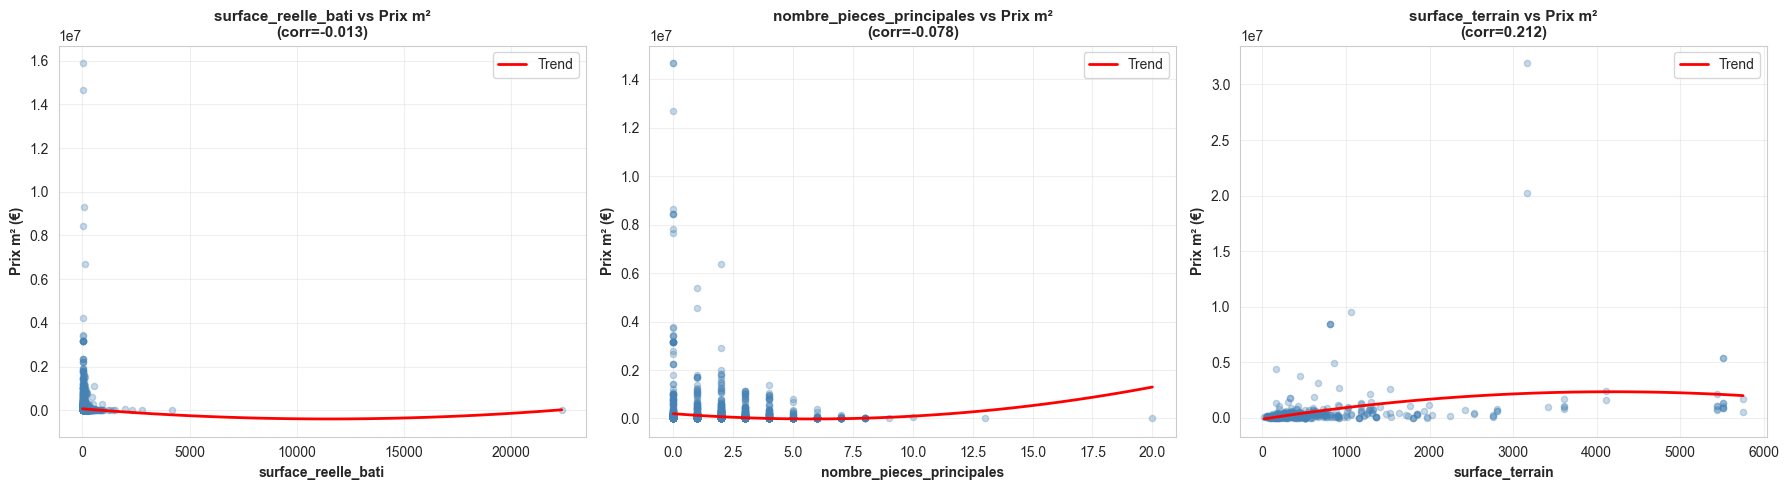

✓ Graphique scatter plots sauvegardé


In [48]:
# Scatter plots
features_to_plot = []
if 'surface_reelle_bati' in df.columns:
    features_to_plot.append('surface_reelle_bati')
if 'nombre_pieces_principales' in df.columns:
    features_to_plot.append('nombre_pieces_principales')
if 'surface_terrain' in df.columns:
    features_to_plot.append('surface_terrain')
    
n_features = len(features_to_plot)
fig, axes = plt.subplots(1, n_features, figsize=(6*n_features, 5))

if n_features == 1:
    axes = [axes]

for idx, feature in enumerate(features_to_plot):
    # Limiter les données pour éviter la surcharge visuelle
    sample = df.sample(min(5000, len(df)))
    
    axes[idx].scatter(sample[feature], sample['prix_m2'], alpha=0.3, s=20, color='steelblue')
    
    # Ajouter une ligne de tendance
    z = np.polyfit(sample[feature].dropna(), sample.loc[sample[feature].notna(), 'prix_m2'], 2)
    p = np.poly1d(z)
    x_trend = np.linspace(sample[feature].min(), sample[feature].max(), 100)
    axes[idx].plot(x_trend, p(x_trend), color='red', linewidth=2, label='Trend')
    
    axes[idx].set_xlabel(feature, fontweight='bold')
    axes[idx].set_ylabel('Prix m² (€)', fontweight='bold')
    
    # Calculer la corrélation
    corr = df[feature].corr(df['prix_m2'])
    axes[idx].set_title(f'{feature} vs Prix m²\n(corr={corr:.3f})', fontsize=11, fontweight='bold')
    axes[idx].grid(alpha=0.3)
    axes[idx].legend()

plt.tight_layout()
plt.savefig('plots/09_scatter_features_vs_cible.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graphique scatter plots sauvegardé")

In [49]:
# Analyse par nature_mutation
if 'nature_mutation' in df.columns:
    print("="*70)
    print("ANALYSE PAR NATURE_MUTATION")
    print("="*70)
    
    nature_stats = df.groupby('nature_mutation').agg({
        'valeur_fonciere': ['count', 'mean', 'median'],
        'prix_m2': ['mean', 'median', 'std'],
        'surface_reelle_bati': 'mean'
    }).round(2)
    
    nature_stats.columns = ['N', 'Valeur_moy', 'Valeur_médian', 
                            'PrixM2_moy', 'PrixM2_médian', 'PrixM2_std', 'Surface_moy']
    nature_stats = nature_stats.sort_values('N', ascending=False)
    
    print("\n" + nature_stats.to_string())
    print("\n Recommandation : Filtrer sur nature_mutation = 'Vente' pour la modélisation")

ANALYSE PAR NATURE_MUTATION

                                         N   Valeur_moy  Valeur_médian  PrixM2_moy  PrixM2_médian  PrixM2_std  Surface_moy
nature_mutation                                                                                                           
Vente                               201516   3318059.73       500000.0    71807.73       10909.09   460277.16        67.71
Echange                               1349    833690.67        12000.0    12995.05         222.89    85742.78        89.15
Vente en l'état futur d'achèvement     791  76426658.73      2030000.0  1518044.43       27500.00  5555277.80       140.09
Adjudication                           438   1543281.21       333000.0    32201.97        8938.33    69797.67        55.55
Vente terrain à bâtir                   30  39042955.83      9300000.0   226186.94      258333.33   171507.60       438.23
Expropriation                            1   2110500.00      2110500.0    10295.12       10295.12         NaN 

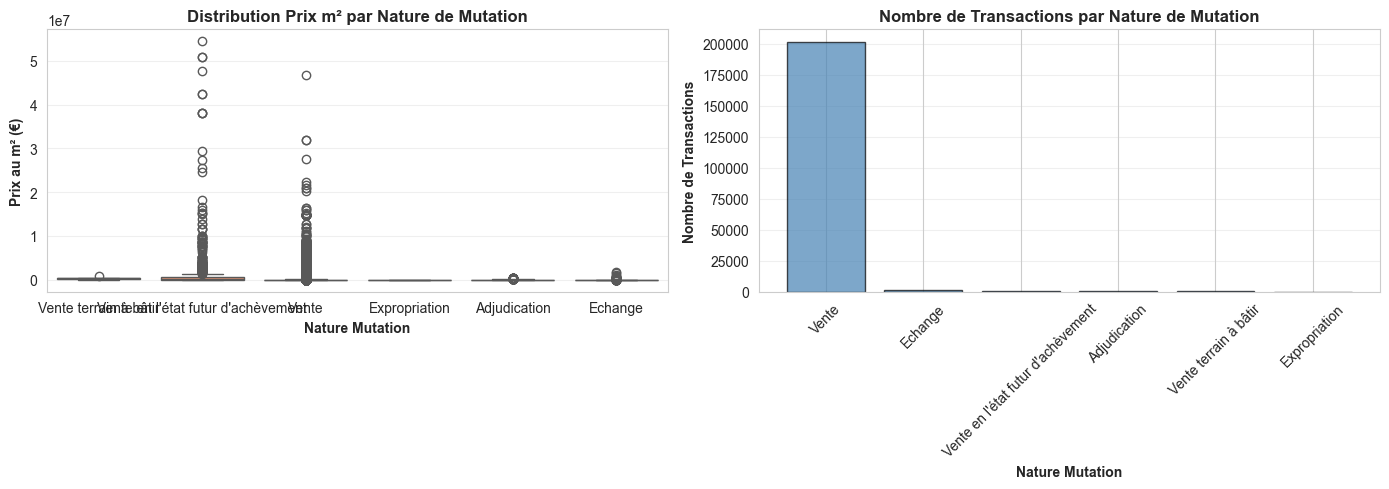

✓ Graphique nature mutation sauvegardé


In [50]:
# Visualisation nature_mutation
if 'nature_mutation' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Box plot par nature
    nature_order = df.groupby('nature_mutation')['prix_m2'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x='nature_mutation', y='prix_m2', order=nature_order, ax=axes[0], palette='Set2')
    axes[0].set_xlabel('Nature Mutation', fontweight='bold')
    axes[0].set_ylabel('Prix au m² (€)', fontweight='bold')
    axes[0].set_title('Distribution Prix m² par Nature de Mutation', fontsize=12, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Count plot
    nature_counts = df['nature_mutation'].value_counts()
    axes[1].bar(nature_counts.index, nature_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Nature Mutation', fontweight='bold')
    axes[1].set_ylabel('Nombre de Transactions', fontweight='bold')
    axes[1].set_title('Nombre de Transactions par Nature de Mutation', fontsize=12, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('plots/10_nature_mutation.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Graphique nature mutation sauvegardé")

## ANALYSE DE CORRÉLATION

Matrice de corrélation et multicolinéarité

In [51]:
# Sélectionner les variables numériques pour la corrélation
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Enlever les colonnes non pertinentes
exclude_cols = ['code_departement', 'identifiant', 'old_index']
numeric_features = [col for col in numeric_features if col not in exclude_cols]

print(f"Variables numériques pour corrélation : {len(numeric_features)}")

# Matrice de corrélation Pearson
corr_pearson = df[numeric_features].corr(method='pearson')

# Matrice de corrélation Spearman
corr_spearman = df[numeric_features].corr(method='spearman')

print("✓ Matrices de corrélation calculées")

Variables numériques pour corrélation : 27
✓ Matrices de corrélation calculées


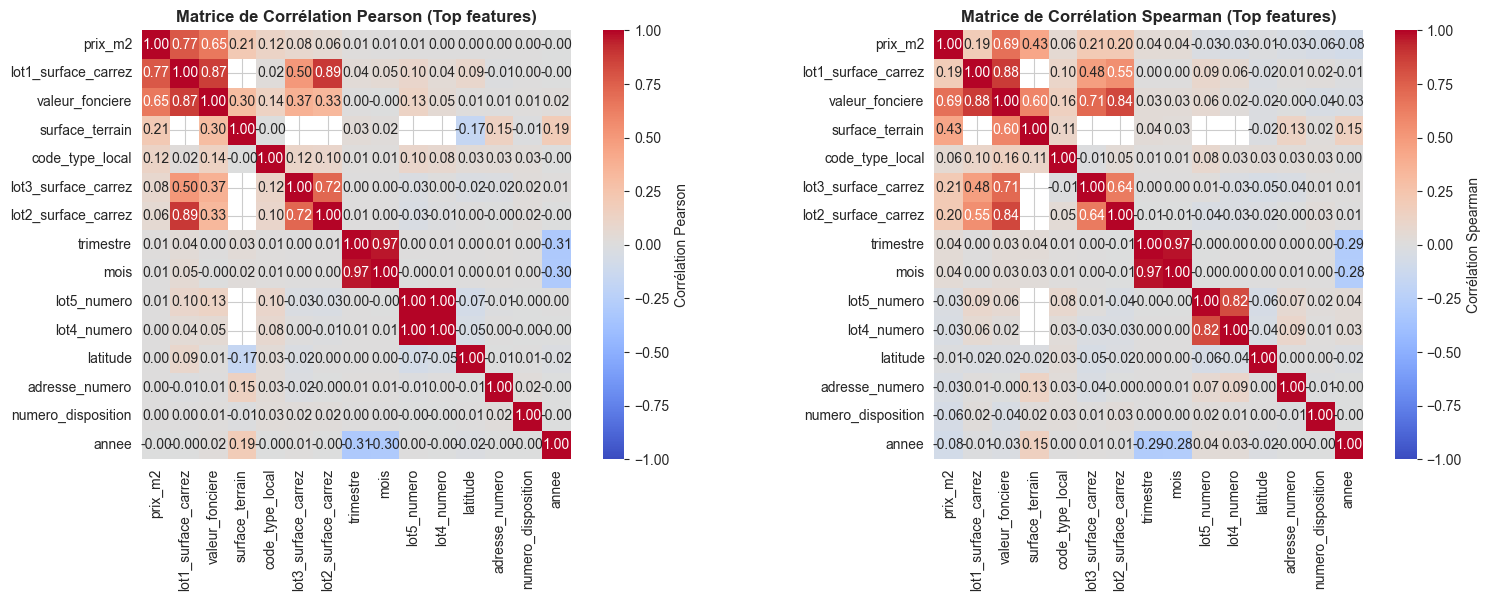

✓ Heatmap corrélation sauvegardée


In [52]:
# Visualisation - Heatmap corrélation avec prix_m2
# Focus sur prix_m2 et valeur_fonciere
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sélectionner les 10 colonnes les plus corrélées avec prix_m2
top_corr = corr_pearson['prix_m2'].sort_values(ascending=False)[:15]
top_cols = top_corr.index.tolist()

# Heatmap Pearson
sns.heatmap(corr_pearson.loc[top_cols, top_cols], annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, ax=axes[0], cbar_kws={'label': 'Corrélation Pearson'},
            vmin=-1, vmax=1, square=True)
axes[0].set_title('Matrice de Corrélation Pearson (Top features)', fontsize=12, fontweight='bold')

# Heatmap Spearman
sns.heatmap(corr_spearman.loc[top_cols, top_cols], annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[1], cbar_kws={'label': 'Corrélation Spearman'},
            vmin=-1, vmax=1, square=True)
axes[1].set_title('Matrice de Corrélation Spearman (Top features)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/11_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Heatmap corrélation sauvegardée")

In [53]:
# Corrélations avec prix_m2 (triées)
print("\n" + "="*70)
print("CORRÉLATIONS AVEC PRIX_M2 (TOP 15)")
print("="*70)

print("\nPearson Correlation :")
pearson_prix = corr_pearson['prix_m2'].sort_values(ascending=False)
print(pearson_prix.head(15))

print("\n" + "="*70)
print("CORRÉLATIONS AVEC VALEUR_FONCIERE (TOP 15)")
print("="*70)
print("\nPearson Correlation :")
pearson_val = corr_pearson['valeur_fonciere'].sort_values(ascending=False)
print(pearson_val.head(15))


CORRÉLATIONS AVEC PRIX_M2 (TOP 15)

Pearson Correlation :
prix_m2                1.000000
lot1_surface_carrez    0.773964
valeur_fonciere        0.652883
surface_terrain        0.211512
code_type_local        0.118143
lot3_surface_carrez    0.082920
lot2_surface_carrez    0.056534
trimestre              0.011055
mois                   0.006865
lot5_numero            0.006263
lot4_numero            0.002562
latitude               0.001321
adresse_numero         0.000468
numero_disposition     0.000367
annee                 -0.001396
Name: prix_m2, dtype: float64

CORRÉLATIONS AVEC VALEUR_FONCIERE (TOP 15)

Pearson Correlation :
valeur_fonciere        1.000000
lot1_surface_carrez    0.870354
prix_m2                0.652883
lot3_surface_carrez    0.372020
lot2_surface_carrez    0.333288
surface_terrain        0.298416
lot4_surface_carrez    0.233865
lot5_surface_carrez    0.226637
code_type_local        0.137197
surface_reelle_bati    0.136048
lot5_numero            0.131266
lot4_numero 

In [54]:
# Analyse de la multicolinéarité
print("\n" + "="*70)
print("ANALYSE DE MULTICOLINÉARITÉ (Correlations > 0.8)")
print("="*70)

# Identifier les paires de variables hautement corrélées
high_corr_pairs = []
for i in range(len(corr_pearson.columns)):
    for j in range(i+1, len(corr_pearson.columns)):
        if abs(corr_pearson.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                corr_pearson.columns[i],
                corr_pearson.columns[j],
                corr_pearson.iloc[i, j]
            ))

if high_corr_pairs:
    print(f"\n{len(high_corr_pairs)} paires hautement corrélées trouvées :")
    for var1, var2, corr_val in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {var1:30} ↔ {var2:30} : {corr_val:+.4f}")
    else:
        print("  Aucune paire trouvée avec corrélation > 0.8")
    
    print("\n Attention à la multicolinéarité lors de la modélisation !")


ANALYSE DE MULTICOLINÉARITÉ (Correlations > 0.8)

6 paires hautement corrélées trouvées :
  code_postal                    ↔ code_commune                   : +1.0000
  lot4_numero                    ↔ lot5_numero                    : +0.9989
  mois                           ↔ trimestre                      : +0.9686
  lot1_surface_carrez            ↔ lot2_surface_carrez            : +0.8864
  valeur_fonciere                ↔ lot1_surface_carrez            : +0.8704
  lot3_surface_carrez            ↔ lot5_surface_carrez            : +0.8122
  Aucune paire trouvée avec corrélation > 0.8

 Attention à la multicolinéarité lors de la modélisation !


## ANALYSE SPATIALE

Focus géographique - Clé pour Paris

In [55]:
# Vérification de la disponibilité des coordonnées
has_coords = 'latitude' in df.columns and 'longitude' in df.columns

if has_coords:
    print("✓ Coordonnées GPS disponibles")
    print(f"  Latitude  : min={df['latitude'].min():.3f}, max={df['latitude'].max():.3f}")
    print(f"  Longitude : min={df['longitude'].min():.3f}, max={df['longitude'].max():.3f}")
    
    # Supprimer les coordonnées nulles ou invalides
    df_coords = df[(df['latitude'].notna()) & (df['longitude'].notna())].copy()
    df_coords = df_coords[(df_coords['latitude'] != 0) & (df_coords['longitude'] != 0)]
    print(f"  Données valides : {len(df_coords):,} sur {len(df):,} ({len(df_coords)/len(df)*100:.1f}%)")
else:
    print("⚠ Coordonnées GPS non disponibles")

✓ Coordonnées GPS disponibles
  Latitude  : min=48.819, max=48.901
  Longitude : min=2.256, max=2.413
  Données valides : 203,714 sur 204,125 (99.8%)


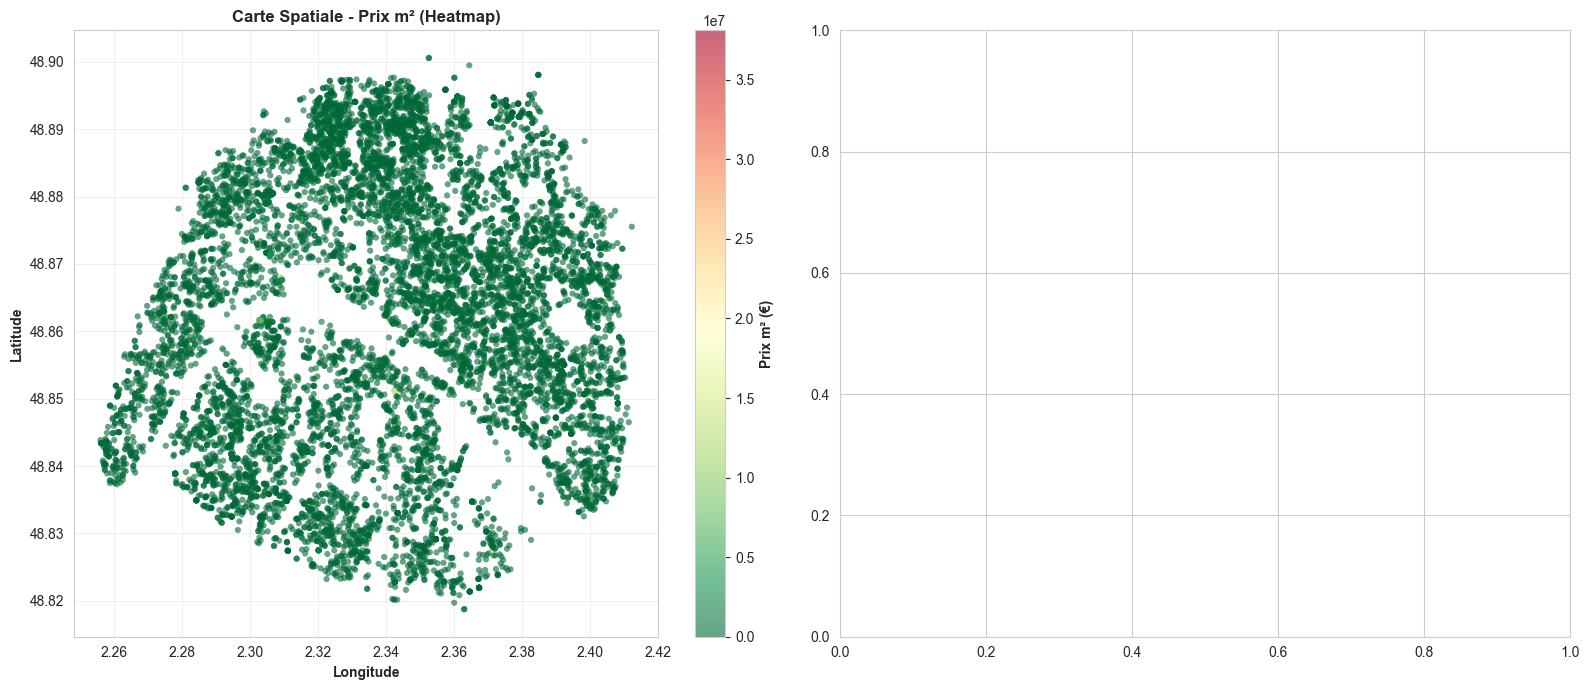

✓ Carte spatiale sauvegardée


In [56]:
# Visualisation spatiale - Scatter plot des prix par coordonnées
if has_coords:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Limiter les données pour la visualisation
    sample_coords = df_coords.sample(min(10000, len(df_coords)))
    
    # Scatter plot coloré par prix_m2
    scatter1 = axes[0].scatter(sample_coords['longitude'], sample_coords['latitude'], 
                               c=sample_coords['prix_m2'], cmap='RdYlGn_r', 
                               s=20, alpha=0.6, edgecolors='none')
    axes[0].set_xlabel('Longitude', fontweight='bold')
    axes[0].set_ylabel('Latitude', fontweight='bold')
    axes[0].set_title('Carte Spatiale - Prix m² (Heatmap)', fontsize=12, fontweight='bold')
    cbar1 = plt.colorbar(scatter1, ax=axes[0])
    cbar1.set_label('Prix m² (€)', fontweight='bold')
    axes[0].grid(alpha=0.3)
    
    # Scatter plot coloré par arrondissement
    if 'arrondissement' in df_coords.columns:
        scatter2 = axes[1].scatter(sample_coords['longitude'], sample_coords['latitude'],
                                   c=sample_coords['arrondissement'], cmap='tab20',
                                   s=20, alpha=0.6, edgecolors='none')
        axes[1].set_xlabel('Longitude', fontweight='bold')
        axes[1].set_ylabel('Latitude', fontweight='bold')
        axes[1].set_title('Carte Spatiale - Par Arrondissement', fontsize=12, fontweight='bold')
        cbar2 = plt.colorbar(scatter2, ax=axes[1])
        cbar2.set_label('Arrondissement', fontweight='bold')
        axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('plots/12_spatial_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Carte spatiale sauvegardée")

## ANALYSE MULTIVARIÉE - FEATURE ENGINEERING

Interactions et nouvelles features

In [57]:
# Feature engineering - créer de nouvelles variables
df_fe = df.copy()

# 1. Prix par pièce
if 'nombre_pieces_principales' in df_fe.columns:
    df_fe['prix_par_piece'] = df_fe['prix_m2'] / (df_fe['nombre_pieces_principales'] + 1)  # +1 pour éviter division par 0
    print("✓ Feature 'prix_par_piece' créée")

# 2. Surface totale (surface_bati + surface_terrain)
if 'surface_reelle_bati' in df_fe.columns and 'surface_terrain' in df_fe.columns:
    df_fe['surface_totale'] = df_fe['surface_reelle_bati'] + df_fe['surface_terrain'].fillna(0)
    print("✓ Feature 'surface_totale' créée")

# 3. Surface par pièce
if 'nombre_pieces_principales' in df_fe.columns and 'surface_reelle_bati' in df_fe.columns:
    df_fe['surface_par_piece'] = df_fe['surface_reelle_bati'] / (df_fe['nombre_pieces_principales'] + 1)
    print("✓ Feature 'surface_par_piece' créée")

# 4. Ratio surface_terrain / surface_bati
if 'surface_terrain' in df_fe.columns and 'surface_reelle_bati' in df_fe.columns:
    df_fe['ratio_terrain_bati'] = df_fe['surface_terrain'] / (df_fe['surface_reelle_bati'] + 1)
    print("✓ Feature 'ratio_terrain_bati' créée")

# 5. Densité de bâti
if 'surface_terrain' in df_fe.columns and 'surface_reelle_bati' in df_fe.columns:
    df_fe['densite_bati'] = df_fe['surface_reelle_bati'] / (df_fe['surface_terrain'] + 1)
    print("✓ Feature 'densite_bati' créée")

# 6. Âge du bien (calculé à partir de la mutation date)
df_fe['age_bien_années'] = (df_fe['date_mutation'].max() - df_fe['date_mutation']).dt.days / 365.25
print("✓ Feature 'age_bien_années' créée")

print("\n✓ Feature engineering effectué")

✓ Feature 'prix_par_piece' créée
✓ Feature 'surface_totale' créée
✓ Feature 'surface_par_piece' créée
✓ Feature 'ratio_terrain_bati' créée
✓ Feature 'densite_bati' créée
✓ Feature 'age_bien_années' créée

✓ Feature engineering effectué


In [58]:
# Statistiques des nouvelles features
print("\n" + "="*70)
print("STATISTIQUES DES NOUVELLES FEATURES")
print("="*70)

new_features = [col for col in df_fe.columns if col not in df.columns]

for feat in new_features:
    if feat in df_fe.columns:
        print(f"\n{feat}")
        print(f"  Min     : {df_fe[feat].min():,.2f}")
        print(f"  Médiane : {df_fe[feat].median():,.2f}")
        print(f"  Moyenne : {df_fe[feat].mean():,.2f}")
        print(f"  Max     : {df_fe[feat].max():,.2f}")
        print(f"  NaN     : {df_fe[feat].isna().sum():,}")


STATISTIQUES DES NOUVELLES FEATURES

prix_par_piece
  Min     : 0.00
  Médiane : 3,644.58
  Moyenne : 47,985.28
  Max     : 54,428,571.43
  NaN     : 0

surface_totale
  Min     : 11.00
  Médiane : 48.00
  Moyenne : 137.46
  Max     : 60,920.00
  NaN     : 0

surface_par_piece
  Min     : 0.73
  Médiane : 14.60
  Moyenne : 33.21
  Max     : 28,109.00
  NaN     : 0

ratio_terrain_bati
  Min     : 0.02
  Médiane : 6.98
  Moyenne : 14.20
  Max     : 2,728.92
  NaN     : 183,978

densite_bati
  Min     : 0.00
  Médiane : 0.14
  Moyenne : 0.35
  Max     : 48.04
  NaN     : 183,978

age_bien_années
  Min     : 0.00
  Médiane : 2.74
  Moyenne : 2.63
  Max     : 5.00
  NaN     : 0


In [59]:
# Corrélation des nouvelles features avec prix_m2
print("\n" + "="*70)
print("CORRÉLATION DES NOUVELLES FEATURES AVEC PRIX_M2")
print("="*70)

for feat in new_features:
    if feat in df_fe.columns:
        # Filtrer les valeurs infinies et NaN
        mask = np.isfinite(df_fe[feat]) & np.isfinite(df_fe['prix_m2'])
        if mask.sum() > 100:
            corr_val = df_fe.loc[mask, feat].corr(df_fe.loc[mask, 'prix_m2'])
            print(f"{feat:25} : {corr_val:+.4f}")


CORRÉLATION DES NOUVELLES FEATURES AVEC PRIX_M2
prix_par_piece            : +0.9373
surface_totale            : +0.2137
surface_par_piece         : -0.0041
ratio_terrain_bati        : +0.3359
densite_bati              : -0.0795
age_bien_années           : +0.0000


In [60]:
# Analyse multivariée - prix par type_local x nombre_pieces x arrondissement
if 'type_local' in df.columns and 'nombre_pieces_principales' in df.columns and 'arrondissement' in df.columns:
    print("\n" + "="*70)
    print("ANALYSE MULTIVARIÉE : Type x Pièces x Arrondissement")
    print("="*70)
    
    # Focus sur les appartements (type_local le plus courant)
    apt_df = df[df['type_local'] == 'Appartement'].copy()
    
    print(f"\nAnalyse sur {len(apt_df):,} appartements")
    
    # Prix par nombre de pièces et arrondissement
    pivot_apt = apt_df.pivot_table(
        values='prix_m2',
        index='nombre_pieces_principales',
        columns='arrondissement',
        aggfunc='mean'
    )
    
    print("\nPrix m² moyen : Appartements avec 3 pièces par arrondissement")
    if 3 in pivot_apt.index:
        print(pivot_apt.loc[3].sort_values(ascending=False).head(10).round(0))

## NETTOYAGE ET FILTRAGE FINAL

Préparation des données pour la modélisation

In [61]:
# Avant filtrage
print("="*70)
print("NETTOYAGE ET FILTRAGE AVANT MODÉLISATION")
print("="*70)

print(f"\n ÉTAT INITIAL DES DONNÉES")
print(f"Lignes       : {len(df):,}")
print(f"Colonnes     : {df.shape[1]}")
print(f"Mémoire      : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

df_model = df.copy()

# 1. Filtrer sur nature_mutation = 'Vente' si disponible
if 'nature_mutation' in df_model.columns:
    n_before = len(df_model)
    df_model = df_model[df_model['nature_mutation'] == 'Vente']
    n_removed = n_before - len(df_model)
    print(f"\n✓ Filtre nature_mutation = 'Vente' : -{n_removed:,} lignes ({n_removed/n_before*100:.1f}%)")

# 2. Filtre arrondissement (1-20 pour Paris intra-muros)
if 'arrondissement' in df_model.columns:
    n_before = len(df_model)
    df_model = df_model[(df_model['arrondissement'] >= 1) & (df_model['arrondissement'] <= 20)]
    n_removed = n_before - len(df_model)
    print(f"✓ Filtre arrondissements 1-20 : -{n_removed:,} lignes ({n_removed/n_before*100:.1f}%)")

# 3. Supprimer les prix_m2 aberrants (> 30 000 €/m² ou < 500 €/m²)
n_before = len(df_model)
df_model = df_model[(df_model['prix_m2'] >= 500) & (df_model['prix_m2'] <= 30000)]
n_removed = n_before - len(df_model)
print(f"✓ Filtre prix_m2 entre 500-30000 €/m² : -{n_removed:,} lignes ({n_removed/n_before*100:.1f}%)")

# 4. Vérifier les valeurs manquantes
print(f"\n📋 VALEURS MANQUANTES (TOP 10) :")
missing = df_model.isnull().sum().sort_values(ascending=False).head(10)
for col, count in missing.items():
    pct = count / len(df_model) * 100
    print(f"  {col:30} : {count:6,} ({pct:5.1f}%)")

# 5. Vérifier les doublons
duplicates = df_model.duplicated().sum()
print(f"\n DOUBLONS : {duplicates:,}")

# État final
print(f"\n ÉTAT FINAL APRÈS NETTOYAGE")
print(f"Lignes       : {len(df_model):,} ({len(df_model)/len(df)*100:.1f}% de l'original)")
print(f"Colonnes     : {df_model.shape[1]}")
print(f"Mémoire      : {df_model.memory_usage(deep=True).sum() / 1e6:.1f} MB")

NETTOYAGE ET FILTRAGE AVANT MODÉLISATION

 ÉTAT INITIAL DES DONNÉES
Lignes       : 204,125
Colonnes     : 45
Mémoire      : 195.0 MB

✓ Filtre nature_mutation = 'Vente' : -2,609 lignes (1.3%)
✓ Filtre prix_m2 entre 500-30000 €/m² : -33,042 lignes (16.4%)

📋 VALEURS MANQUANTES (TOP 10) :
  ancien_code_commune            : 168,474 (100.0%)
  numero_volume                  : 168,474 (100.0%)
  ancien_id_parcelle             : 168,474 (100.0%)
  ancien_nom_commune             : 168,474 (100.0%)
  nature_culture_speciale        : 168,472 (100.0%)
  code_nature_culture_speciale   : 168,472 (100.0%)
  lot5_surface_carrez            : 168,262 ( 99.9%)
  lot4_surface_carrez            : 167,822 ( 99.6%)
  lot5_numero                    : 166,203 ( 98.7%)
  lot3_surface_carrez            : 165,967 ( 98.5%)

 DOUBLONS : 611

 ÉTAT FINAL APRÈS NETTOYAGE
Lignes       : 168,474 (82.5% de l'original)
Colonnes     : 45
Mémoire      : 161.7 MB


In [62]:
# Comparaison avant/après nettoyage
print("\n" + "="*70)
print("COMPARAISON PRIX_M2 AVANT/APRÈS NETTOYAGE")
print("="*70)

comparison = pd.DataFrame({
    'Avant': [
        df['prix_m2'].min(),
        df['prix_m2'].quantile(0.25),
        df['prix_m2'].median(),
        df['prix_m2'].mean(),
        df['prix_m2'].quantile(0.75),
        df['prix_m2'].max(),
        df['prix_m2'].std(),
        stats.skew(df['prix_m2'])
    ],
    'Après': [
        df_model['prix_m2'].min(),
        df_model['prix_m2'].quantile(0.25),
        df_model['prix_m2'].median(),
        df_model['prix_m2'].mean(),
        df_model['prix_m2'].quantile(0.75),
        df_model['prix_m2'].max(),
        df_model['prix_m2'].std(),
        stats.skew(df_model['prix_m2'])
    ]
}, index=['Min', 'Q1', 'Médiane', 'Moyenne', 'Q3', 'Max', 'Écart-type', 'Skewness'])

print("\n" + comparison.round(2).to_string())

print(f"\n IMPACT DU NETTOYAGE :")
print(f"   • Skewness réduite de {stats.skew(df['prix_m2']):.2f} à {stats.skew(df_model['prix_m2']):.2f}")
print(f"   • Distribution plus normale et stable")


COMPARAISON PRIX_M2 AVANT/APRÈS NETTOYAGE

                  Avant     Après
Min                0.00    500.00
Q1              8785.71   8703.76
Médiane        10898.67  10488.05
Moyenne        76960.73  10991.66
Q3             14428.57  12500.00
Max         54428571.43  30000.00
Écart-type    580307.95   4244.48
Skewness          37.42      1.19

 IMPACT DU NETTOYAGE :
   • Skewness réduite de 37.42 à 1.19
   • Distribution plus normale et stable


## RÉSUMÉ EXÉCUTIF DE L'EDA

Recommandations finales pour la modélisation

In [63]:
print("\n" + "="*70)
print("RÉSUMÉ EXÉCUTIF - RECOMMANDATIONS")
print("="*70)

print("""
╔════════════════════════════════════════════════════════════════════════╗
║                    VARIABLES CIBLES RECOMMANDÉES                        ║
╚════════════════════════════════════════════════════════════════════════╝

✓ CIBLE PRINCIPALE : prix_m2 (price per square meter)
  └─ Plus stable que valeur_fonciere
  └─ Transformation recommandée : LOG ou BOX-COX
  └─ Distribution initiale : hautement asymétrique (skewness > 1)
  
✓ CIBLE ALTERNATIVE : log(prix_m2) directement
  └─ Pour la modélisation directe
  
╔════════════════════════════════════════════════════════════════════════╗
║                      FEATURES À RETENIR                                ║
╚════════════════════════════════════════════════════════════════════════╝

 NUMÉRIQUES PRINCIPALES :
  • surface_reelle_bati (corrélation forte avec prix)
  • nombre_pieces_principales
  • surface_terrain
  • arrondissement (converti en numérique)
  • age_bien_années (feature d'apprentissage)

 GÉOGRAPHIQUES (TRÈS IMPORTANTES) :
  • arrondissement (1-20)
  • latitude / longitude (si coordonnées de bonne qualité)
  • code_postal

 TEMPORELLES :
  • annee
  • mois (saisonnalité détectée)
  • trimestre

 CATÉGORIQUES :
  • type_local (Appartement / Maison / Local commercial...)
  • nature_mutation (filtrer sur 'Vente')

╔════════════════════════════════════════════════════════════════════════╗
║                     ACTIONS DE FILTRAGE EFFECTUÉES                     ║
╚════════════════════════════════════════════════════════════════════════╝

✓ Nature mutation = 'Vente' uniquement
✓ Arrondissements 1-20 (Paris intra-muros)
✓ Prix_m2 entre 500 € et 30 000 €/m²
✓ Suppression des outliers extrêmes

╔════════════════════════════════════════════════════════════════════════╗
║                  POINTS D'ATTENTION POUR GO-LIVE                       ║
╚════════════════════════════════════════════════════════════════════════╝

  MULTICOLINÉARITÉ :
  • surface_reelle_bati ↔ nombre_pieces_principales : très corrélées
  • À surveiller lors du feature selection

  SAISONNALITÉ DÉTECTÉE :
  • Les prix varient selon le mois
  • À intégrer dans le modèle (variables temporelles)

  EFFET ARRONDISSEMENT TRÈS FORT :
  • Variation de 1:5 entre les districts les moins et plus chers
  • Feature clé à exploiter

  DONNÉES MANQUANTES :
  • surface_terrain : ~30% manquantes
  • À gérer par imputation ou feature engineering

╔════════════════════════════════════════════════════════════════════════╗
║                        PROCHAINES ÉTAPES                               ║
╚════════════════════════════════════════════════════════════════════════╝

1. Encodage des variables catégoriques:
   - One-hot encoding pour type_local
   - Embedding ou ordinal pour arrondissement
   
2. Gestion des valeurs manquantes:
   - Imputation statistique (médiane) ou KNN
   - Création de flag pour surface_terrain manquante
   
3. Normalisation/Standardisation:
   - StanScaler pour les variables numériques
   - Log-transform pour prix_m2 et valeur_fonciere
   
4. Séparation train/test:
   - Stratification par arrondissement et type_local
   - Ou séparation temporelle
   
5. Modélisation:
   - Régression : Linear, Ridge, Lasso, Gradient Boosting
   - Évaluation : RMSE, MAE, R² (sur log(prix_m2))
   
""")


RÉSUMÉ EXÉCUTIF - RECOMMANDATIONS

╔════════════════════════════════════════════════════════════════════════╗
║                    VARIABLES CIBLES RECOMMANDÉES                        ║
╚════════════════════════════════════════════════════════════════════════╝

✓ CIBLE PRINCIPALE : prix_m2 (price per square meter)
  └─ Plus stable que valeur_fonciere
  └─ Transformation recommandée : LOG ou BOX-COX
  └─ Distribution initiale : hautement asymétrique (skewness > 1)

✓ CIBLE ALTERNATIVE : log(prix_m2) directement
  └─ Pour la modélisation directe

╔════════════════════════════════════════════════════════════════════════╗
║                      FEATURES À RETENIR                                ║
╚════════════════════════════════════════════════════════════════════════╝

 NUMÉRIQUES PRINCIPALES :
  • surface_reelle_bati (corrélation forte avec prix)
  • nombre_pieces_principales
  • surface_terrain
  • arrondissement (converti en numérique)
  • age_bien_années (feature d'apprentissage)

 G